In [46]:
import torch
from src.models.retinanet import RetinaNet
from src.utils import remove_duplicates, inflate_annots, visualize_detections, remove_low_confidence_edge_boxes
from src.io import load_model_weights
import os
from PIL import Image
from torchvision import transforms
import json

In [47]:
MEAN=(0.485, 0.456, 0.406)
STD=(0.229, 0.224, 0.225)

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [49]:
model = RetinaNet(state_dict=load_model_weights("saved_weights", "annotator_weights.pth")).to(device)
model.eval()


Model weights successfully loaded from: saved_weights/annotator_weights.pth


RetinaNet(
  (model): RetinaNet(
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, momentum=

In [50]:
inputs_path = "./unannotated_input"
inputs = os.listdir(inputs_path)
path_inputs = [os.path.join(inputs_path, input) for input in inputs]
path_inputs

['./unannotated_input/2_jpg.rf.0ffdaf7fc98b8a0a16a3f00c88bb7faa.jpg',
 './unannotated_input/tile_0000.png',
 './unannotated_input/tile_0002.png',
 './unannotated_input/tile_0001.png']

In [51]:
image_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

In [52]:
predictions = []
image_tensors = []
SCORE_THRESH = 0.2
for input in path_inputs:
    image_tensor = image_transforms(Image.open(input)).to(device)
    image_tensors.append(image_tensor)
    with torch.inference_mode():
        prediction = model(image_tensor.unsqueeze(0))[0]
        output_mask = prediction["scores"] >= SCORE_THRESH
        prediction = {
            "boxes": prediction["boxes"][output_mask].to(device),
            "labels": torch.tensor(list(range(len(output_mask)))).to(device),
            "scores": prediction["scores"][output_mask].to(device)
        }
        removed_duplicates = remove_duplicates(prediction, iou_threshold=-0.1)
        inflated_annots = inflate_annots(removed_duplicates, image_tensor.shape[1], image_tensor.shape[2], 0, 0.3)
        edge_cleaned_annots = remove_low_confidence_edge_boxes(inflated_annots, image_tensor.shape[1], image_tensor.shape[2], 0.5, 0.01)
        predictions.append(edge_cleaned_annots)

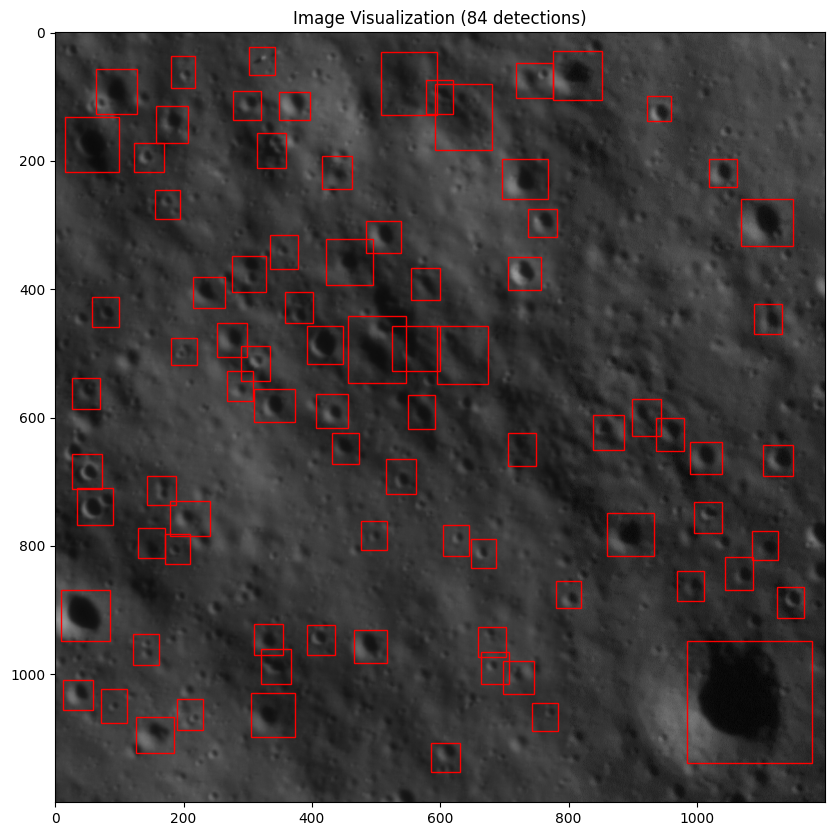

In [53]:
visualize_detections(image_tensors[3], predictions[3], show_labels=False)

In [54]:
predictions[0]["boxes"].shape

torch.Size([77, 4])

```json
{
    "0": [10, 20, 30, 40],
    "1": [30, 10, 5, 60]
}
```

In [55]:
def to_dict(prediction_boxes):
    json_dict = dict()

    for i, box in enumerate(prediction_boxes):
        json_dict[str(i)] = box.cpu().int().tolist()
    
    return json_dict

In [56]:
json_dicts = []
for prediction in predictions:
    json_dicts.append(to_dict(prediction["boxes"]))

In [57]:
file_names  = [ ".".join(i.split(".")[:-1]) + ".json" for i in inputs ]
file_names

['2_jpg.rf.0ffdaf7fc98b8a0a16a3f00c88bb7faa.json',
 'tile_0000.json',
 'tile_0002.json',
 'tile_0001.json']

In [61]:
save_json(json_dicts, file_names, output_dir="./annotated_output")